<h2>credits</h2>
<ul><li>
Prof. Jeff Erickson's exposition - <a href="https://jeffe.cs.illinois.edu/teaching/algorithms/notes/J-approx.pdf">click here</a></li><li>
Graham, R. L. “Bounds on Multiprocessing Timing Anomalies.” SIAM Journal on Applied Mathematics, vol. 17, no. 2, 1969, pp. 416–29. JSTOR, <a href="http://www.jstor.org/stable/2099572">click here</a></li></ul>

<hr>
Imagine you have a list of  𝑛   tasks to be done (in parallel) by  𝑚   processors. Note that  𝑚< 𝑛 , of course, or else the problem is trivial: just assign each job to its own processor and we can be done as fast as needed.

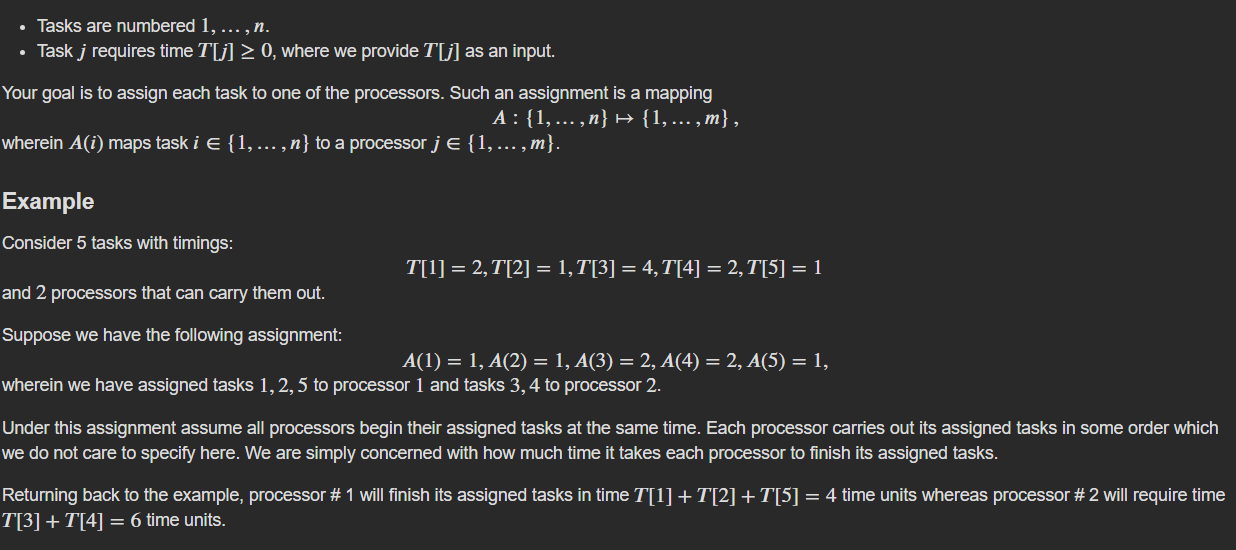


<h2>Makespan</h2>

The makespan of an assignment is the time taken by the longest running processor to finish all of its assigned tasks. In the example above, the makespan is given by 6 time units since processor # 2 which is the longest running takes 6 units of time to finish its assigned tasks.

<i>
Our goal is to find an assignment  𝐴   that assigns  𝑛  given tasks with timings  𝑇[1],…,𝑇[𝑛]
  to  𝑚  processors in a way that minimizes the makespan of the assignment  𝐴.
</i>

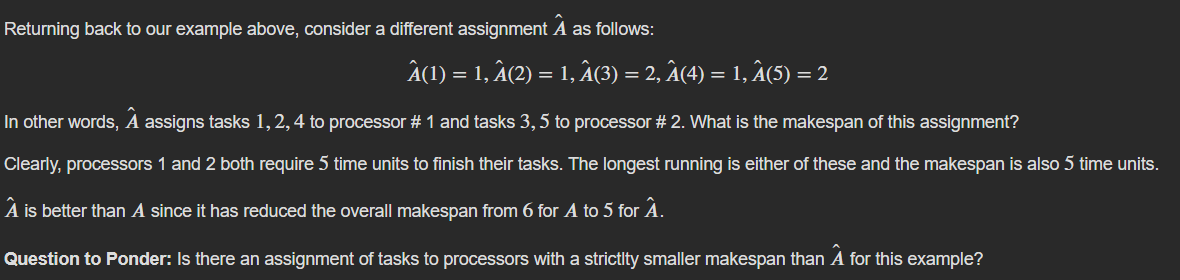

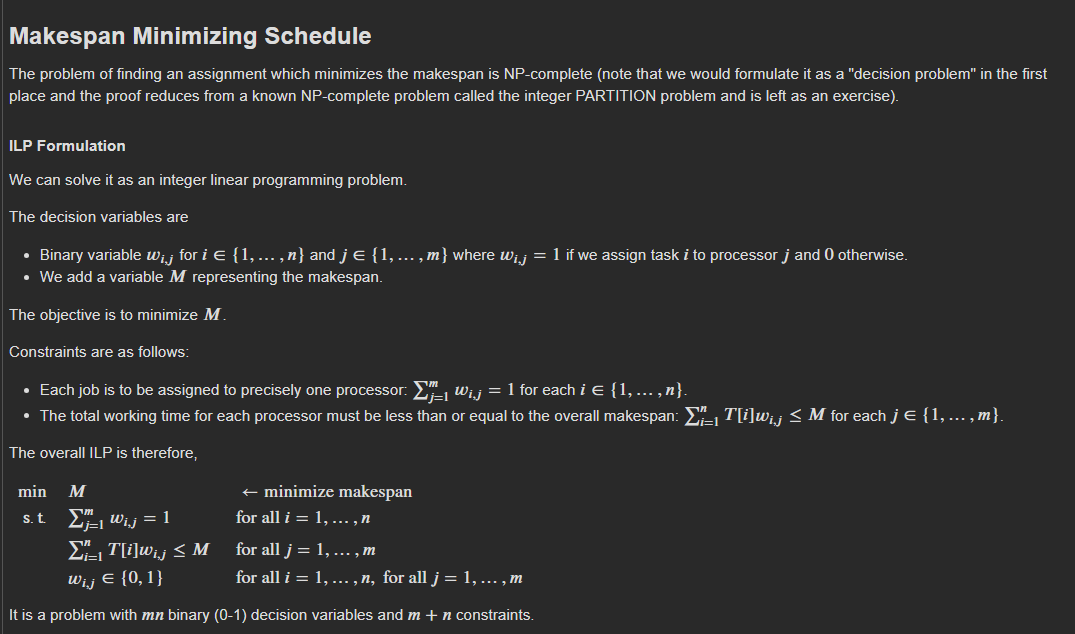

In [2]:
from pulp import *

def formulate_min_makespan(task_times, m):
    n = len(task_times)
    assert m < n
    prob = LpProblem('min-makespan', LpMinimize)
    # create a list of list of indicator variables w_i_j
    indicator_vars = [ [LpVariable(f'w_{i}_{j}', cat='Binary') for j in range(m)] for i in range(n) ]
    M = LpVariable('M', cat='Continuous') # create a variable M for makespan -- it is real-valued
    # set objective
    prob += M
    # add constraints
    # each task must be assigned to exactly one processor
    for i in range(n): 
        # for each task - indicator_vars[i] is array of variables indicating assignments of i to various processors (total m)
        prob += lpSum(indicator_vars[i]) == 1 # one task should be assigned to only one processor

    # working time for each processor must be less than the makespan
    for j in range(m):
        vars_i = [indicator_vars[i][j] for i in range(n)] # collects all jobs assigned to jth processor in order 1 to n
        prob += lpDot(task_times, vars_i) <= M # lpDot is a very useful function that pulp supports to take dot product of two lists
    # solve and extract answer
    prob.solve()
    assert prob.status == constants.LpStatusOptimal
    # extract the job assignment
    A = []
    for i in range(n):
        w_list = indicator_vars[i] # collects all indicator vars that represent ith job assigned from (1,m) processors
        ## TODO: Replace code below using a suitable python list API function
        assigned_proc = None
        for j in range(m):
            if w_list[j].varValue > 0:
                assigned_proc = j
                break
        assert assigned_proc != None, f'Task # {i} did not get assigned to any processor. There is a bug in problem formulation'
        A.append(assigned_proc)
    return (A, M.varValue)
    

In [3]:
(A, mkSpan) = formulate_min_makespan([2,1,4,2,1], 2)
print('Assignment')
print('----------------------')
for i in range(5):
    print(f'Task # {i+1} assigned to processor # {A[i]+1}')
print(f'MakeSpan is {mkSpan}')

Assignment
----------------------
Task # 1 assigned to processor # 1
Task # 2 assigned to processor # 1
Task # 3 assigned to processor # 2
Task # 4 assigned to processor # 1
Task # 5 assigned to processor # 2
MakeSpan is 5.0


In [9]:
(A, mkSpan) = formulate_min_makespan([5,6,2,5,2,1,3,4], 3)
print('Assignment')
print('----------------------')
for i in range(8):
    print(f'Task # {i+1} assigned to processor # {A[i]+1}')
print(f'MakeSpan is {mkSpan}')

Assignment
----------------------
Task # 1 assigned to processor # 1
Task # 2 assigned to processor # 3
Task # 3 assigned to processor # 1
Task # 4 assigned to processor # 2
Task # 5 assigned to processor # 2
Task # 6 assigned to processor # 1
Task # 7 assigned to processor # 2
Task # 8 assigned to processor # 3
MakeSpan is 10.0


<h2>Approximation Algorithm</h2>

Unfortunately, <u>ILPs have an exponential running time in terms of the number of jobs and processors</u>. Unless P = NP, we cannot really hope for a polynomial time solution.

However, we will now formulate an approximation algorithm which will solve the same problem but will have a guaranteed approximation ratio. In particular, we will guarantee that

𝑀<sup>∗</sup>≤𝑀<sub>appr</sub>≤2𝑀<sup>∗</sup>
 

where  𝑀<sup>∗</sup>  is the <u>best possible make-span (that computed by the ILP for instance)</u> and  𝑀<sub>appr</sub>
  is the makespan for the (suboptimal) assignment provided by our algorithm.

Although our approximation algorithm provides a suboptimal solution, it is guaranteed to be within a <u>factor of 2</u> of the best possible solution.

<h3>Greedy Approximation Algorithm for minimizing makespan</h3>

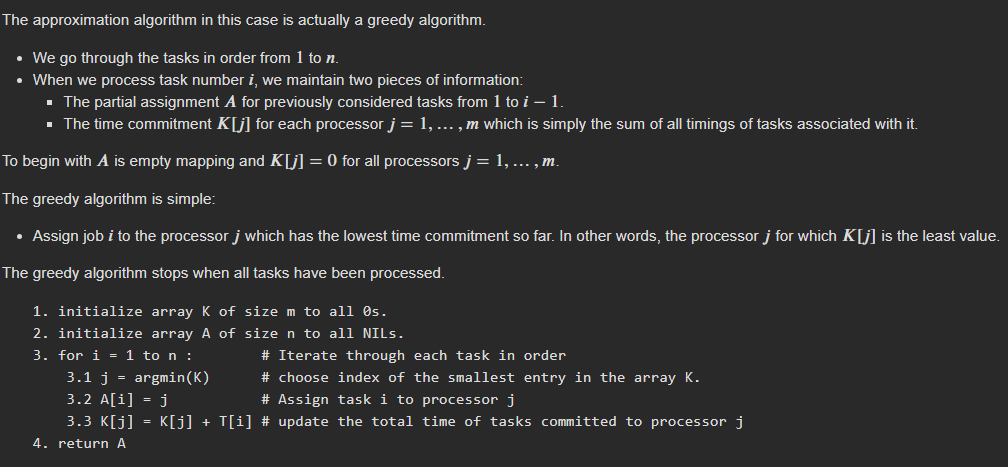

In [4]:
def greedy_jobshop_scheduling(timings, m):
    n = len(timings)
    A = []
    K = [(0,j) for j in range(m)] # for simplicity of coding maintain K as a array of tuples consisting of timing and processor index
    for i in range(n):
        print(f'K = {K}')
        (min_proc_timing, min_proc_idx) = min(K) # this can be improvedd using a priority queue but right now this will take O(m) time
        A.append(min_proc_idx) 
        print(f'Task {i} assigned to processor {min_proc_idx}')
        K[min_proc_idx] = (min_proc_timing + timings[i], min_proc_idx) # update the array K
    print(f'K = {K}')
    makeSpan, max_proc_idx = max(K)
    print(f'Make span = {makeSpan}')
    return A

    

In [10]:
A = greedy_jobshop_scheduling([5,6,2,5,2,1,3,4], 3)

K = [(0, 0), (0, 1), (0, 2)]
Task 0 assigned to processor 0
K = [(5, 0), (0, 1), (0, 2)]
Task 1 assigned to processor 1
K = [(5, 0), (6, 1), (0, 2)]
Task 2 assigned to processor 2
K = [(5, 0), (6, 1), (2, 2)]
Task 3 assigned to processor 2
K = [(5, 0), (6, 1), (7, 2)]
Task 4 assigned to processor 0
K = [(7, 0), (6, 1), (7, 2)]
Task 5 assigned to processor 1
K = [(7, 0), (7, 1), (7, 2)]
Task 6 assigned to processor 0
K = [(10, 0), (7, 1), (7, 2)]
Task 7 assigned to processor 1
K = [(10, 0), (11, 1), (7, 2)]
Make span = 11


: 

In [ ]:
(A, mkSpan) = formulate_min_makespan([2,1,4,2,1], 2)
A = greedy_jobshop_scheduling([2,1,4,2,1], 2)
print('Assignment')
print('----------------------')
for i in range(5):
    print(f'Task # {i+1} assigned to processor # {A[i]+1}')
print(f'MakeSpan is {mkSpan}')

<h2>Analysis of Greedy Algorithm</h2>

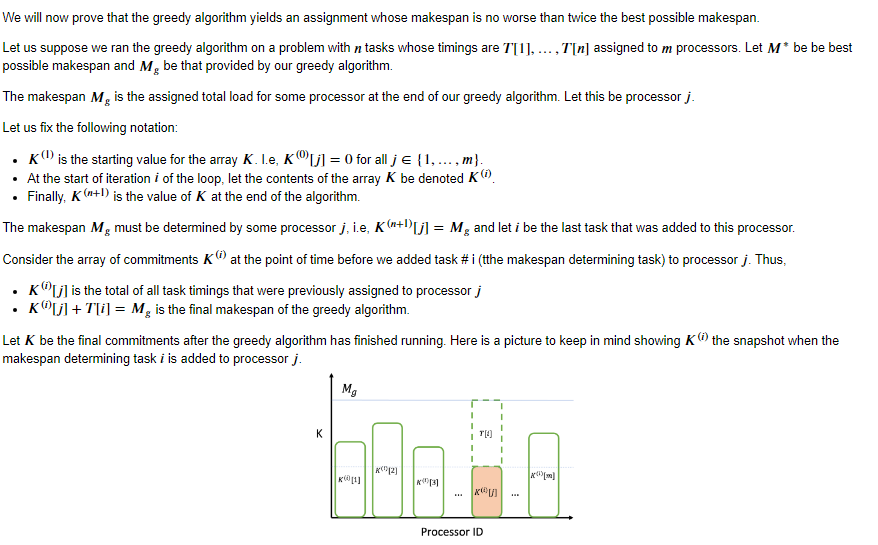

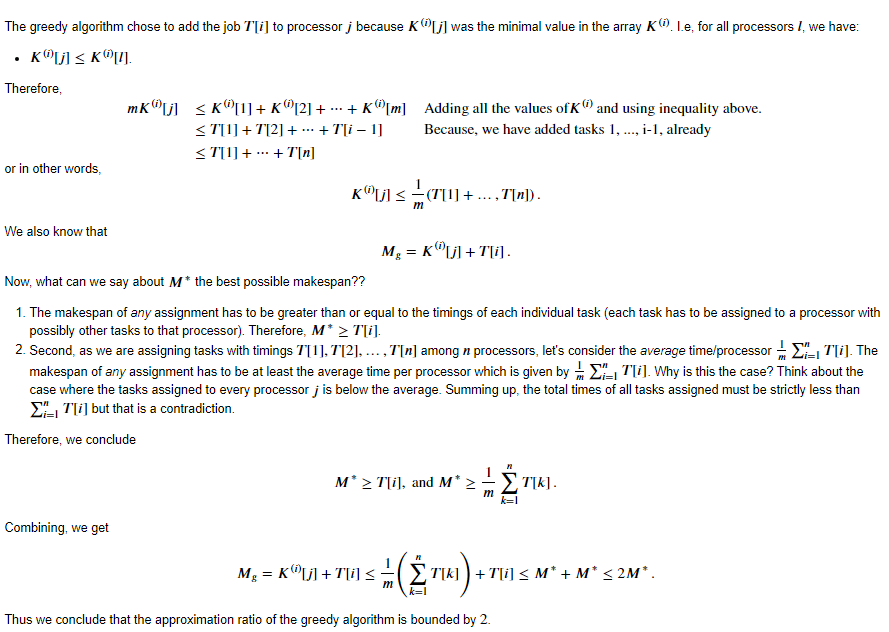

<h3> More Fine-Grained Analysis </h3>

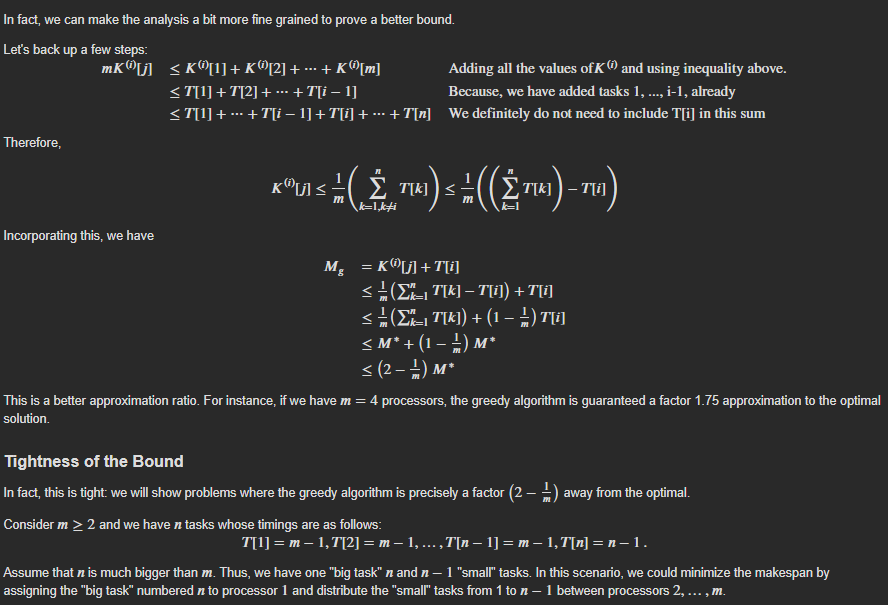

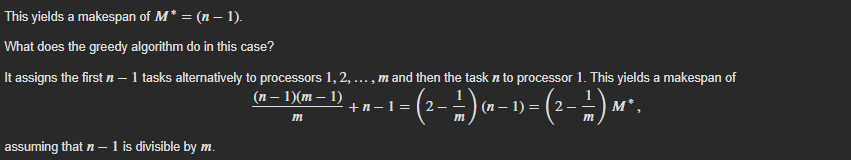

<h3>Improved Algorithm: Sorting the tasks </h3>

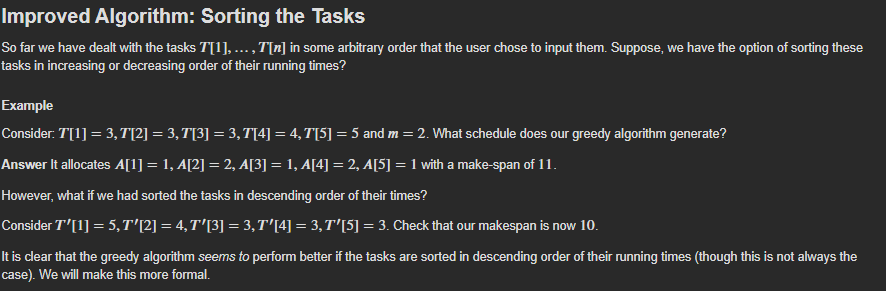

In [6]:
def greedy_jobshop_scheduling_sorted(T, m):
    # First sort the array T provided but as we do so remember the indices in the old array
    # When we refer to Task # i, we are refering to its index in the array T.
    timings = [(ti, j) for (j, ti) in enumerate(T)] # Store each task and index
    timings.sort(reverse=True) # Sort it in reverse order
    n = len(timings)
    A = [-1] * n # Initialize the assignment to -1 (dummy value)
    K = [(0,j) for j in range(m)] # for simplicity of coding maintain K as a array of tuples consisting of timing and processor index
    for (ti, ti_idx) in timings: # iterate through the array of times and indices into original array
        print(f'K = {K}')
        (min_proc_timing, min_proc_idx) = min(K) # this can be improved using a priority queue but right now this will take O(m) time
        A[ti_idx]= min_proc_idx # Assign the task ti_idx to processor min_proc_idx with minimum load so far.
        print(f'Task {ti_idx} assigned to processor {min_proc_idx}') 
        K[min_proc_idx] = (min_proc_timing + ti, min_proc_idx) # update the array K
    print(f'K = {K}')
    makeSpan, max_proc_idx = max(K)
    print(f'Make span = {makeSpan}')
    return A

In [7]:
A = greedy_jobshop_scheduling_sorted([1,1,1,1,1,1,1,1,1,1,1,1,1,1,5], 4)

K = [(0, 0), (0, 1), (0, 2), (0, 3)]
Task 14 assigned to processor 0
K = [(5, 0), (0, 1), (0, 2), (0, 3)]
Task 13 assigned to processor 1
K = [(5, 0), (1, 1), (0, 2), (0, 3)]
Task 12 assigned to processor 2
K = [(5, 0), (1, 1), (1, 2), (0, 3)]
Task 11 assigned to processor 3
K = [(5, 0), (1, 1), (1, 2), (1, 3)]
Task 10 assigned to processor 1
K = [(5, 0), (2, 1), (1, 2), (1, 3)]
Task 9 assigned to processor 2
K = [(5, 0), (2, 1), (2, 2), (1, 3)]
Task 8 assigned to processor 3
K = [(5, 0), (2, 1), (2, 2), (2, 3)]
Task 7 assigned to processor 1
K = [(5, 0), (3, 1), (2, 2), (2, 3)]
Task 6 assigned to processor 2
K = [(5, 0), (3, 1), (3, 2), (2, 3)]
Task 5 assigned to processor 3
K = [(5, 0), (3, 1), (3, 2), (3, 3)]
Task 4 assigned to processor 1
K = [(5, 0), (4, 1), (3, 2), (3, 3)]
Task 3 assigned to processor 2
K = [(5, 0), (4, 1), (4, 2), (3, 3)]
Task 2 assigned to processor 3
K = [(5, 0), (4, 1), (4, 2), (4, 3)]
Task 1 assigned to processor 1
K = [(5, 0), (5, 1), (4, 2), (4, 3)]
Task 0

<h3>Analysis of Greedy Scheduling under Sorting</h3>

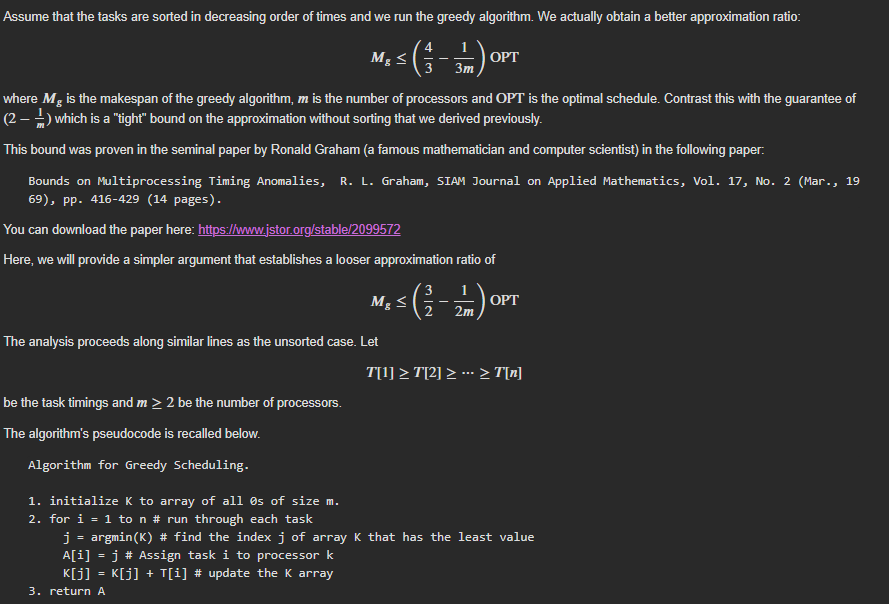

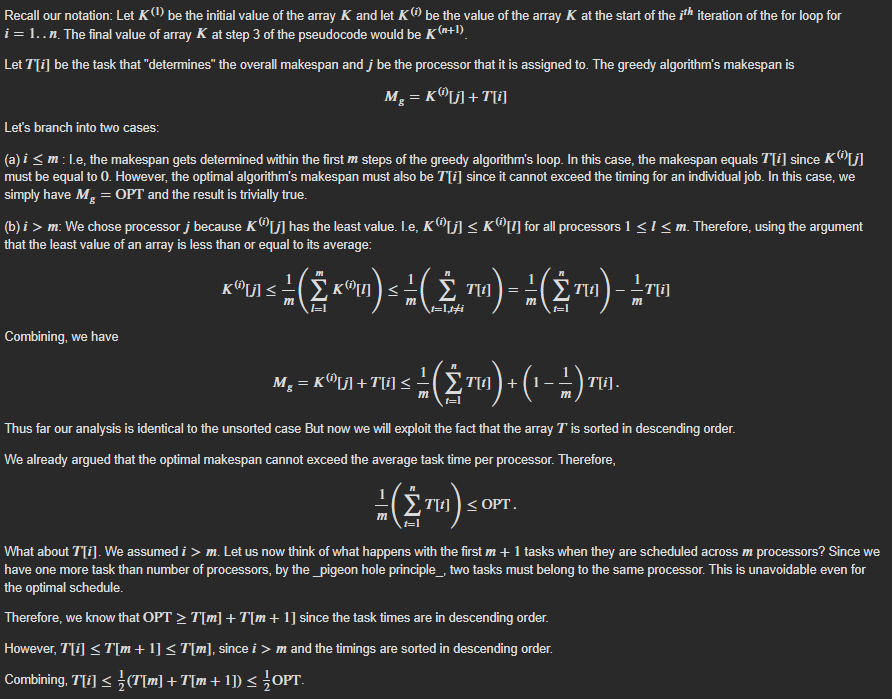

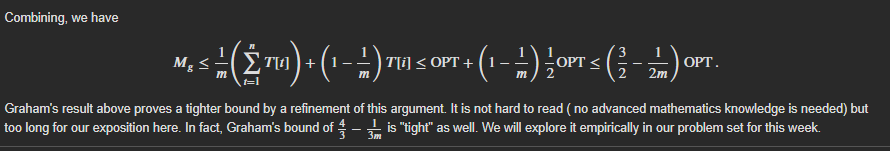